In [139]:
include("main.jl")

ventana_llegada_pasajeros_1!

# Parametros

In [140]:
longitud_total_linea = 445.0
n_zonas = 3
g = 20.0
n_trenes,n_nodos = 6,10
n_pasajeros = 4

# ==========================================================
# BIG M
# ==========================================================

M = 1e4
#tiemoi cambio de aguja
varsigma = 3.0
#presupuesto disponible en MUSD
presupuesto = 100.0
#escala peso para construccion de laderos
beta = 100

E = 60*24 #minutos del dia

v_carga, v_pasajeros = 50.0,70.0 #velocidad en km/h

W_pasajero, W_carga = 15.0, 1.0 #peso en retrasar horarios
tolerancia_salida = 30 #min
tolerancia_llegada = 120 #min
t_max_ladero = 40 #min

40

# Conjuntos 

In [141]:
Q,Qe,Qc,P,N = crear_instancias(n_trenes,n_nodos)
direccion = crear_diecciones(N,n_trenes)
origen, destino = crear_origen_destino(N,Q,direccion)
tipo = generar_tipos_tren(N, n_pasajeros)
N_pasajeros = [i for i in N if tipo[i] == 1]
N_carga = [i for i in N if tipo[i] == 0];

In [142]:
b_plus, b_minus  = pares_mis_op_sentido(N)
Q_i, P_i = visitados_Q_P(Q,P)
Omega = conjunto_Omega(b_plus,b_minus,P_i)
ThetaSet = Conjunto_Theta(b_plus,b_minus,Q)
C = conjunto_zonas(n_zonas)
Kappa = conjunto_kappa(Qe,Qc)
Zset = conjunto_Z(Q,C)
sigma = sigma_zonas(C,longitud_total_linea);

In [143]:
#fijamos manualmente donde hay laderos o estaciones existentes
phi = Dict()
phi[1] = 0.0
phi[n_nodos] = longitud_total_linea ;

In [144]:
lambda_prog,lambda_min, lambda_max = construir_lambdas(Qe, phi, 70, tolerancia_llegada);

In [145]:
U = costo_zonas(C;alpha = 5)
headway = headways(N, P, tipo;h_pasajero=5.0,h_mixto=10.0,h_carga=15.0)
v_T = v_trenes(N,tipo ;v_carga,v_pasajeros)
#longitud_total = 445.0
#longitud_segmento = generar_longitudes(P, longitud_total)
#tiempo_segmento = tiempo_segemento(N,P,longitud_segmento,v_T)
tau = generar_tau(N,Q,Qe,tipo)
f =  generar_f(N, tipo)
t_ladero = generar_t_ladero(N,Q)
#zonas = generar_zonas(Qc)
#costo_ladero =generar_costos_ladero(Qc, zonas)
W = generar_pesos(N, tipo;W_pasajero ,W_carga )
horario_salida = generar_horario_salida(N, direccion; intervalo = 20.0);

# Vaiables del modelo

In [146]:
model = Model(HiGHS.Optimizer)
set_attribute(model, "time_limit", 15*60.0)
set_attribute(model, "mip_rel_gap", 0.01)

In [147]:
A,D,o,retraso,d = variables_1!(model,N,Q)
z,x,theta = variables_2!(model,Zset,Omega,ThetaSet);

# Funcion Objetivo

In [148]:
funcion_objetivo!(model, N,Q,origen,horario_salida,W,retraso,A, D,z, Zset, U, beta);

# Restriccion llegada-salida

In [149]:
ventana_salida!(model, N, origen, horario_salida, D,tolerancia_salida);

In [150]:
#ventana_llegada_pasajeros_1!(model, N_pasajeros, destino, lambda_prog, lambda_max, A)

# Restriccion infaestructura

In [151]:
nodos_existentes!( model,Qe, d, phi);
una_zona_por_ladero!(model, Qc,C, z);
laderos_existentes!(model, Qe, C, z);
activacion_ladero!( model, N, Q, C, M, o, z);
zonas_construccion!(model, Kappa, C,sigma, M, d,z)
separacion_minima!( model, Qc, C, d,z, g,M)
horizonte_tiempo!( model, N,destino, A, E);

# Restriccion de Presupuesto

In [152]:
presupuesto!(model,Qc, C,U,z,presupuesto);

# Restricciones de Movimiento

In [153]:
movimiento_dp!( model,N, P,direccion,A, D, d, v_T)
restriccion_llegada_salida!( model,  N, Q, A,D);
restriccion_activacion_meet_pass!(model, N,Q, M,tau, A,D, o)
restriccion_tiempo_ladero!(model, N, Q,tau,f, t_ladero, varsigma,A, D, o);
#espera_maxima_ladero!(model, N_carga, Q, A, D, tau, o, M, t_max_ladero)
espera_maxima_ladero!(model, N, Q, A, D, tau, o, M, t_max_ladero);

# Restricciones de conflicto

In [154]:
conflicto_mismo_sentido_salida_1!(model,  b_plus,   P, direccion, M, headway, varsigma, D, o,x)
conflicto_mismo_sentido_llegada_1!( model,  b_plus,  P, direccion, M,headway, varsigma, A, o, x)
conflicto_opuesto_1!( model, b_minus,P, direccion, M, headway, varsigma, A, D, x)
#espejo de las anteiores tres
conflicto_mismo_sentido_salida_2!( model, b_plus, P, direccion, M, headway,varsigma,  D, o, x)
conflicto_mismo_sentido_llegada_2!( model, b_plus, P, direccion,  M, headway, varsigma, A, o,x)
conflicto_opuesto_2!( model, b_minus,  P, direccion,  M,  headway, varsigma, A, D, x)

# Restricciones de laderos

In [155]:
restriccion_theta_1!( model, ThetaSet,P, o,x, theta)
restriccion_theta_2!( model, ThetaSet,  P, o, x, theta)
capacidad_ladero!( model, ThetaSet, P,M, varsigma,headway, A,  D, theta)

In [156]:
println(num_variables(model))
println(JuMP.num_constraints(model; count_variable_in_set_constraints = false))

510
1596


# Optimizar modelo

In [157]:
optimize!(model)

println(termination_status(model))
println(primal_status(model))

Running HiGHS 1.13.0 (git hash: 1bce6d5c8): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1596 rows; 510 cols; 5687 nonzeros; 375 integer variables (375 binary)
Coefficient ranges:
  Matrix  [9e-01, 1e+04]
  Cost    [1e+00, 2e+03]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+04]
Presolving model
1554 rows, 502 cols, 5585 nonzeros  0s
1310 rows, 417 cols, 5127 nonzeros  0s
1309 rows, 416 cols, 5128 nonzeros  0s
Presolve reductions: rows 1309(-287); columns 416(-94); nonzeros 5128(-559) 

Solving MIP model with:
   1309 rows
   416 cols (341 binary, 0 integer, 0 implied int., 75 continuous, 0 domain fixed)
   5128 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Tri

TIME_LIMIT
FEASIBLE_POINT


# Diagnostico de Modelo

In [158]:
imprimir_laderos_construidos(Q, C, z, d)


LADEROS CONSTRUIDOS
Nodo 1 | Zona 1 | km = 0.0
Nodo 5 | Zona 2 | km = 174.24
Nodo 6 | Zona 2 | km = 210.25
Nodo 7 | Zona 2 | km = 247.72
Nodo 8 | Zona 3 | km = 377.92
Nodo 10 | Zona 3 | km = 445.0


In [159]:
imprimir_segmentos(P, d)


LONGITUD DE SEGMENTOS
Segmento 1 = 2.92 km
Segmento 2 = 151.32 km
Segmento 3 = 0.0 km
Segmento 4 = 20.0 km
Segmento 5 = 36.01 km
Segmento 6 = 37.47 km
Segmento 7 = 130.19 km
Segmento 8 = 0.0 km
Segmento 9 = 67.08 km


In [160]:
imprimir_nodos(Q, d)


UBICACIÓN DE NODOS
Nodo 1 -> 0.0 km
Nodo 2 -> 2.92 km
Nodo 3 -> 154.24 km
Nodo 4 -> 154.24 km
Nodo 5 -> 174.24 km
Nodo 6 -> 210.25 km
Nodo 7 -> 247.72 km
Nodo 8 -> 377.92 km
Nodo 9 -> 377.92 km
Nodo 10 -> 445.0 km


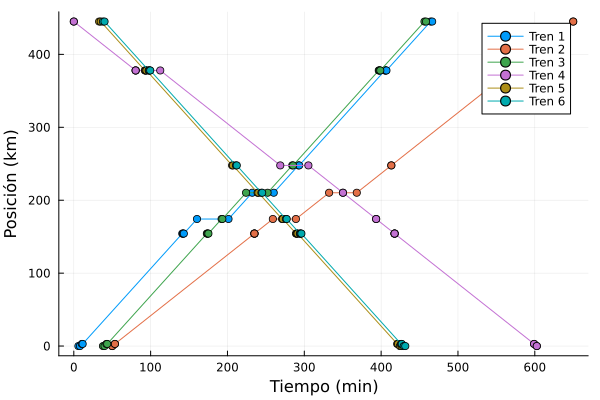

In [161]:
plot_trenes_km( N, Q, A, D, d,direccion)

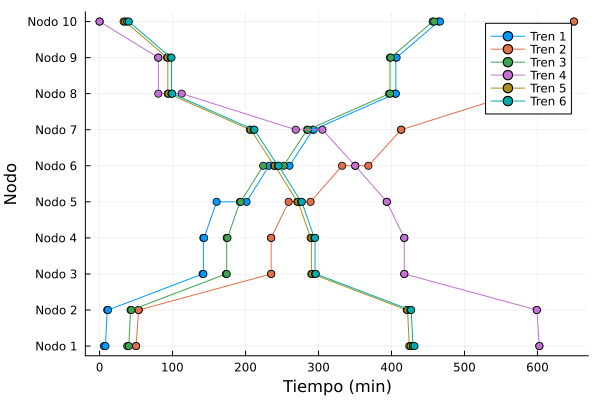

In [162]:
plot_trenes_nodos(N,Q, A, D,direccion)